In [15]:
import yfinance as yf
import pandas as pd

etfs = ["SCHD", "QQQ", "JEPQ"]

price_data = {}
div_data = {}

for etf in etfs:
    ticker = yf.Ticker(etf)
    
    df = ticker.history(start="2020-01-01")
    if df.empty:
        continue

    price_data[etf] = df["Close"]

    div = ticker.dividends
    div_data[etf] = div

price_df = pd.DataFrame(price_data)

# Daily returns
returns_df = price_df.pct_change().dropna()

returns_df.head()

# Cumulative returns
cumulative_returns = (1 + returns_df).cumprod()

cumulative_returns.head()

import matplotlib.ticker as mtick

## 📊 Monthly Return Analysis

In this step, we analyze ETF performance on a monthly basis to identify trends and patterns over time.

In [16]:
# Monthly returns
monthly_returns = price_df.resample('ME').ffill().pct_change()

monthly_returns.head()

,SCHD,QQQ,JEPQ
Date,,,
2020-01-31 00:00:00-05:00,NaN,NaN,NaN
2020-02-29 00:00:00-05:00,-0.093498,-0.060574,NaN
2020-03-31 00:00:00-04:00,-0.118829,-0.072858,NaN
2020-04-30 00:00:00-04:00,0.126056,0.149737,NaN
2020-05-31 00:00:00-04:00,0.036920,0.066009,NaN


## 📈 Data Transformation

To visualize the data more effectively, we reshape it into a pivot table format.

In [17]:
monthly_returns['Year'] = monthly_returns.index.year
monthly_returns['Month'] = monthly_returns.index.month

pivot_qqq = monthly_returns.pivot_table(
    values='QQQ',
    index='Year',
    columns='Month'
)

pivot_qqq

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2020,NaN,-0.060574,-0.072858,0.149737,0.066009,0.062867,0.073465,0.109447,-0.057786,-0.030449,0.112258,0.049024
2021,0.002614,-0.001335,0.017168,0.059098,-0.012012,0.062622,0.028609,0.042187,-0.056832,0.078640,0.019968,0.011524
2022,-0.087470,-0.044760,0.046679,-0.135957,-0.015866,-0.089079,0.125517,-0.051322,-0.105355,0.039998,0.055441,-0.090137
2023,0.106429,-0.003598,0.094927,0.005079,0.078838,0.063038,0.038601,-0.014830,-0.050799,-0.020655,0.108188,0.055870
2024,0.018192,0.052834,0.012750,-0.043738,0.061518,0.064701,-0.016781,0.011039,0.026216,-0.008646,0.053508,0.004540
2025,0.021634,-0.027035,-0.075862,0.013968,0.091783,0.063858,0.024237,0.009540,0.053762,0.047804,-0.015610,-0.006699
2026,0.012306,-0.023445,-0.041545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🔥 Heatmap Visualization

The heatmap shows monthly returns, where red indicates negative returns and green indicates positive returns.

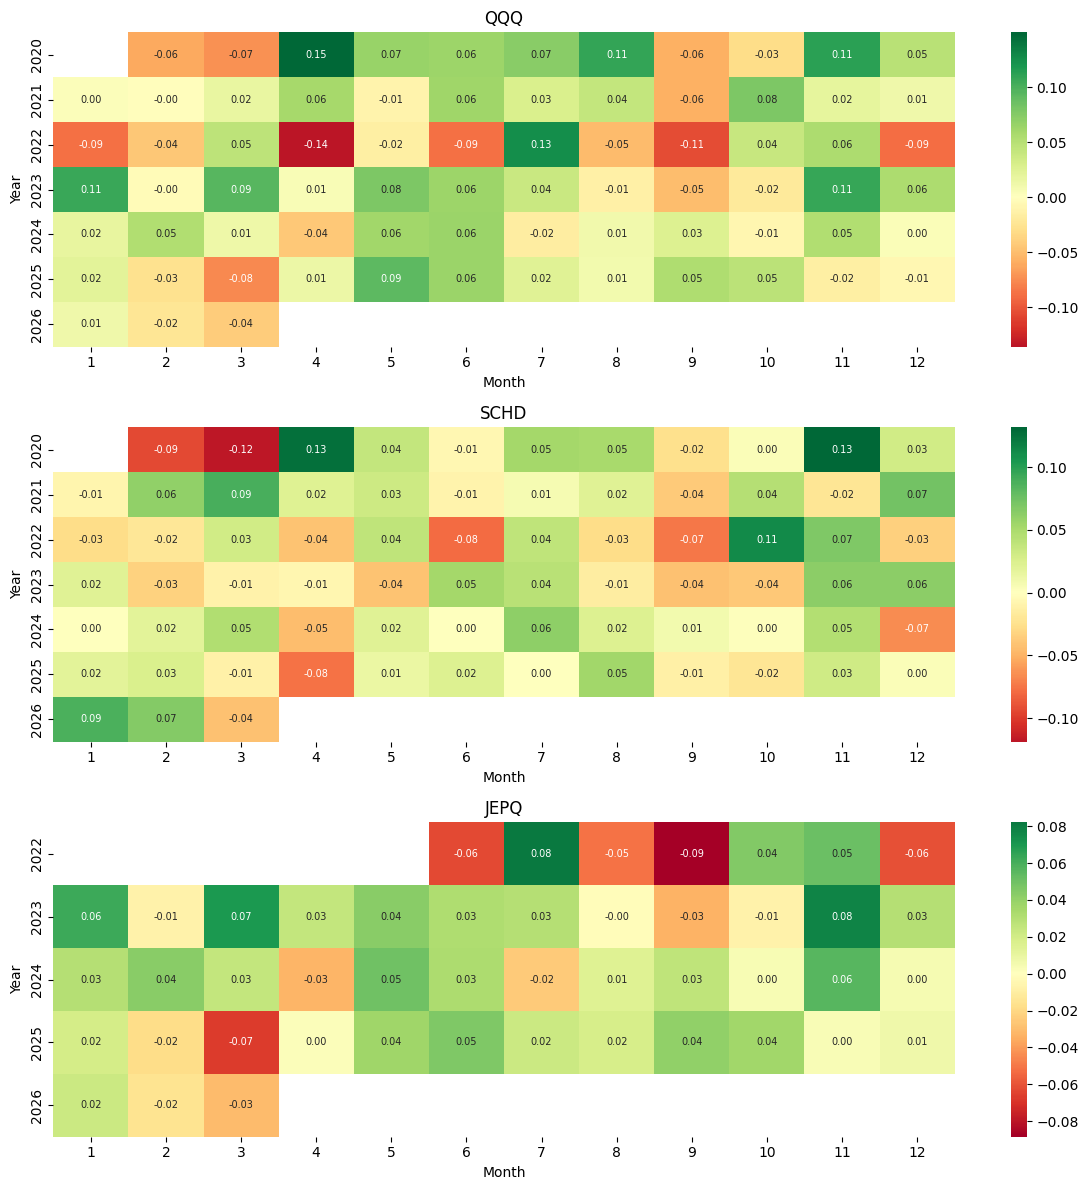

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot_schd = monthly_returns.pivot_table(
    values='SCHD',
    index='Year',
    columns='Month'
)

pivot_jepq = monthly_returns.pivot_table(
    values='JEPQ',
    index='Year',
    columns='Month'
)

fig, axes = plt.subplots(3, 1, figsize=(12,12))

sns.heatmap(
    pivot_qqq,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size":7},
    ax=axes[0]
)
axes[0].set_title("QQQ")

sns.heatmap(
    pivot_schd,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size":7},
    ax=axes[1]
)
axes[1].set_title("SCHD")

sns.heatmap(
    pivot_jepq,
    cmap="RdYlGn",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size":7},
    ax=axes[2]
)
axes[2].set_title("JEPQ")

plt.tight_layout()
plt.savefig("images/heatmap.png")
plt.show()

## 🔍 Key Observations

- QQQ shows strong positive returns during bull markets, especially in 2020–2021  
- SCHD demonstrates more stable monthly returns with fewer extreme fluctuations  
- JEPQ exhibits relatively lower volatility compared to QQQ, especially during market downturns  

- Significant negative returns are observed during 2022, reflecting market instability driven by interest rate hikes  
- Recovery patterns can be seen across all ETFs after major downturn periods 
- JEPQ data starts from 2022 due to its later inception date 

This comparison suggests that while QQQ may exhibit slightly higher volatility, the difference is not as pronounced as commonly expected.

SCHD and JEPQ show somewhat more stable return patterns, but overall, all ETFs display similar levels of fluctuation across different market conditions.

This indicates that, within this time period, differences in volatility between growth and income-focused ETFs are present but not dramatically distinct.